# Phase 2: Unsupervised Learning - Obesity Risk Classification System

In this phase, we move beyond prediction and apply **unsupervised learning** techniques to uncover hidden patterns in the dataset. Rather than relying on class labels, clustering algorithms group individuals purely based on the similarity of their lifestyle and health features.

The goals of this phase are:
- Discover natural groupings (clusters) within the data that the supervised labels alone may not reveal.
- Evaluate and compare two clustering algorithms using multiple metrics.
- Interpret each cluster in terms of obesity risk.
- Propose a strategy for integrating the clustering results with the supervised model built in Phase 1.

> **Note**: The target variable (`NObeyesdad_encoded`) is **removed before clustering**. It is only used afterward (strictly for interpretation) to understand the composition of the discovered clusters.

# Data Preparation

## Why We Start from the Preprocessed Dataset

We load the preprocessed dataset produced in Phase 1. This dataset has already been:
- **Cleaned** (missing values handled, duplicates removed).
- **Encoded** (categorical features converted to numerical form).
- **Normalized** (features scaled to a comparable range).

Reusing this dataset avoids duplicating preprocessing work and ensures that the clustering results are directly comparable to the supervised learning results from Phase 1.


In [2]:
import pandas as pd

df = pd.read_csv("preprocessed_data.csv")
df.head()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_encoded,family_history_with_overweight_encoded,FAVC_encoded,CAEC_encoded,SMOKE_encoded,SCC_encoded,CALC_encoded,MTRANS_encoded,NObeyesdad_encoded
0,0.148936,0.5,0.666667,0.5,0.000000,0.5,0.301162,0,1,0,2,0,0,3,3,1
1,0.148936,1.0,0.666667,1.0,1.000000,0.0,0.297240,0,1,0,2,1,1,2,3,1
2,0.191489,0.5,0.666667,0.5,0.666667,0.5,0.284736,1,1,0,2,0,0,1,3,1
3,0.276596,1.0,0.666667,0.5,0.666667,0.0,0.366359,1,0,0,2,0,0,1,4,5
4,0.170213,0.5,0.000000,0.5,0.000000,0.0,0.405778,1,0,0,2,0,0,2,3,6


## Removing the Target Variable

Before applying any clustering algorithm, the class label (`NObeyesdad_encoded`) **must be removed**.

**Why?** Clustering is an unsupervised task — it should discover natural groupings purely from feature similarities, without being guided by the correct answer. Including the target would leak information and defeat the purpose of unsupervised learning.

The removed label will only be reintroduced later in the **Cluster Interpretation** section to help us understand the meaning of each discovered cluster.

In [3]:
X = df.drop("NObeyesdad_encoded", axis=1)

# Clustering Rationale & Algorithm Selection

Choosing the right clustering algorithm is not arbitrary as it depends on the structure of the data, the expected cluster shapes, and the interpretability requirements of the final system. We selected two algorithms with distinct approaches so that their comparison reveals meaningful insights about the data.

---

## K-Means Clustering

**i. Dataset characteristics (size, feature types, expected cluster shape):**

**• Size:**
Our dataset contains approximately 2,087 records after preprocessing. K-Means is well-suited for this scale. It operates by iteratively reassigning each point to its nearest centroid and updating centroids until convergence. This process is computationally efficient on medium-sized datasets, typically converging in seconds, which makes it practical for both exploration (testing multiple values of k) and final deployment.

**• Feature types:**
All features are numerical after the encoding applied in Phase 1. K-Means computes Euclidean distances between points and centroids, which requires numerical input. Since our data is already fully numerical and normalized, K-Means can operate on it directly without further transformation.

**• Expected cluster shape:**
K-Means assumes that clusters are approximately spherical and similarly sized. Given that our obesity classes represent a roughly ordered spectrum of health risk (from Insufficient Weight through to Obesity Type III) we expect the underlying groups to be relatively compact and separable in feature space, making K-Means a reasonable fit.

**ii. Problem alignment:**
We have 7 original obesity classes, but clustering does not need to mirror this number. The goal is to discover natural groupings that correspond to meaningful health risk profiles, which we determine empirically through the Elbow Method and Silhouette Score.

**iii. Strengths & Weaknesses:**

**• Strengths:**
- Fast and scalable; converges quickly on our dataset.
- Each cluster is summarized by its centroid (average feature values), making results easy to interpret.
- Supports the `predict()` method, meaning new user inputs can be assigned to an existing cluster in real time — critical for integration into the advice system.

**• Weaknesses:**
- Sensitive to the initial random placement of centroids, mitigated by setting `random_state=42`.
- Assumes spherical clusters; may struggle if the true cluster shapes are elongated or irregular.
- The number of clusters k must be specified in advance, which is why we evaluate multiple values before committing.

---

## Agglomerative (Hierarchical) Clustering

**i. Dataset characteristics (size, feature types, expected cluster shape):**

**• Size:**
Agglomerative Clustering builds a hierarchy by starting with every point as its own cluster and progressively merging the two closest clusters until the desired number remains. On ~2,000 records this is computationally manageable, though it is slower than K-Means.

**• Feature types:**
We use Ward linkage, which minimizes total within-cluster variance at each merge step. This criterion works well on numerical, normalized data like ours and produces compact, roughly equal-sized clusters making it the most directly comparable linkage method to K-Means.

**• Expected cluster shape:**
Unlike K-Means, Hierarchical Clustering does not assume spherical clusters. This makes it a valuable comparison point, if both algorithms agree on the cluster structure, we can be more confident that the discovered groupings reflect genuine patterns in the data.

**ii. Problem alignment:**
We use the same k=5 as K-Means to make the metric comparisons directly meaningful. Both algorithms are evaluated under identical conditions.

**iii. Strengths & Weaknesses:**

**• Strengths:**
- Does not rely on centroid-based assignment, offering a fundamentally different perspective on the data structure.
- Ward linkage produces compact clusters that are internally similar to K-Means results, making the comparison meaningful.
- Provides a richer picture of data structure, the merging hierarchy reveals how groups relate to one another at different levels of granularity.

**• Weaknesses:**
- Once a merge is made, it cannot be undone, early incorrect merges propagate through the hierarchy.
- Does not support `predict()` for new data points without refitting, making it less suitable for real-time deployment.
- Computationally heavier than K-Means, especially as dataset size grows.

---

**Summary:** These two algorithms were chosen because they represent fundamentally different clustering philosophies (centroid-based partitioning (K-Means) vs. hierarchical agglomeration). Comparing them allows us to validate whether the discovered cluster structure is robust or dependent on algorithmic assumptions.

# Cluster Determination

Before applying clustering, we need to determine the optimal number of clusters k. We use two complementary methods: the **Elbow Method** (based on WCSS) and **Silhouette Score** analysis. Using two methods together reduces the risk of choosing a suboptimal k based on one criterion alone.

## Elbow Method (WCSS)

The Elbow Method plots the **Within-Cluster Sum of Squares (WCSS)** the total squared distance from each point to its assigned cluster centroid  against the number of clusters k.

**How to read it:** As k increases, WCSS always decreases because more clusters means shorter distances between points and their centroids. The "elbow" is the point where the rate of decrease slows significantly. Beyond that point, adding more clusters yields diminishing returns in terms of compactness. The elbow point gives us the best trade-off between simplicity and cluster quality.

We test k from 2 to 9 and record the WCSS for each value. `inertia_` is sklearn's built-in attribute that stores the WCSS after fitting a KMeans model.

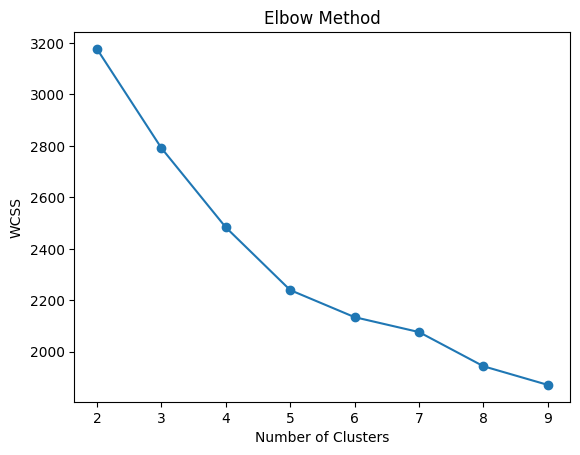

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

**The Elbow Plot:**

Looking at the graph, the WCSS drops steeply from k=2 (~ 3200) to k=4 (~ 2500), then the rate of decrease slows noticeably from k=5 onwards. The curve begins to flatten after k=5, meaning adding more clusters beyond this point does not provide meaningful improvements in compactness. This confirms that **k=5 is the most efficient choice**.

## Silhouette Score Analysis

The **Silhouette Score** measures how similar each data point is to its own cluster compared to the nearest other cluster. It ranges from **-1 to +1**:
- A score near **+1** means the point is well inside its cluster and far from others which is ideal.
- A score near **0** means the point sits on the boundary between two clusters.
- A score near **-1** suggests the point may have been assigned to the wrong cluster.

We compute the average silhouette score across all points for k=4 and k=5. A higher average score indicates better-defined, more meaningful clusters. The k with the higher score is selected as the optimal number of clusters.

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters_4 = kmeans.fit_predict(X)

In [6]:
from sklearn.metrics import silhouette_score

score_4 = silhouette_score(X, clusters_4)
print("Silhouette Score for k=4:", score_4)

Silhouette Score for k=4: 0.28058444802462207


In [7]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters_5 = kmeans.fit_predict(X)

In [8]:
score_5 = silhouette_score(X, clusters_5)
print("Silhouette Score for k=5:", score_5)

Silhouette Score for k=5: 0.2954091716380449


## Cluster Number Decision

**Selected: k = 5**

Based on both methods, **k = 5** was selected as the optimal number of clusters:

- The Elbow Method shows a noticeable reduction in the rate of WCSS decrease around k = 5, indicating diminishing compactness gains beyond this point.
- The Silhouette Score for k = 5 is higher than k = 4, confirming that k = 5 produces better-separated and more cohesive clusters.
- Practically, 5 clusters aligns well with the health risk spectrum of the dataset (ranging from very low risk to very high risk) making the clusters both statistically sound and domain-relevant.

# K-Means Clustering

## Implementation

With k=5 confirmed from the Elbow Method and Silhouette Score analysis, we now train the final K-Means model on the full dataset.

A few important parameters to note:
- **`n_clusters=5`** : the number of clusters we determined in the previous section.
- **`random_state=42`** : fixes the random seed for reproducible centroid initialization — we get the same results every time we run the code.
- **`fit_predict()`** : both fits the model and returns the cluster ID (0–4) for each data point in one step.

We then attach these cluster labels to the dataframe so they can be used for interpretation and for saving the final clustered dataset.

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters_kmeans = kmeans.fit_predict(X)
df["cluster"] = clusters_kmeans

In [10]:
df.head()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_encoded,family_history_with_overweight_encoded,FAVC_encoded,CAEC_encoded,SMOKE_encoded,SCC_encoded,CALC_encoded,MTRANS_encoded,NObeyesdad_encoded,cluster
0,0.148936,0.5,0.666667,0.5,0.000000,0.5,0.301162,0,1,0,2,0,0,3,3,1,4
1,0.148936,1.0,0.666667,1.0,1.000000,0.0,0.297240,0,1,0,2,1,1,2,3,1,3
2,0.191489,0.5,0.666667,0.5,0.666667,0.5,0.284736,1,1,0,2,0,0,1,3,1,1
3,0.276596,1.0,0.666667,0.5,0.666667,0.0,0.366359,1,0,0,2,0,0,1,4,5,1
4,0.170213,0.5,0.000000,0.5,0.000000,0.0,0.405778,1,0,0,2,0,0,2,3,6,1


## Cluster Assignments Overview

The table above shows the first few rows of the dataset with the newly added `cluster` column. Each row has been assigned to one of the 5 clusters (labeled 0–4) based purely on the similarity of its feature values. At this stage the cluster numbers are arbitrary identifiers and their meaning will be revealed in the next section when we examine the feature profiles of each group.

# Cluster Interpretation & Profiles

## Feature Means per Cluster

To understand what each cluster represents, we examine the average value of every feature within each cluster. Since the features were normalized in Phase 1, these means are on a comparable scale, making it easy to spot patterns across clusters.

For example:
- A cluster with a high mean in caloric food consumption and a low mean in physical activity frequency would suggest a high-risk lifestyle group.
- A cluster with a low mean in BMI-related features and a high mean in physical activity would suggest a healthy, low-risk group.

The target variable was not used during clustering and is only reintroduced here (strictly for interpretation) to understand the composition of each discovered cluster.

In [11]:
df.groupby("cluster").mean()

,Age,FCVC,NCP,CH2O,FAF,TUE,BMI,Gender_encoded,family_history_with_overweight_encoded,FAVC_encoded,CAEC_encoded,SMOKE_encoded,SCC_encoded,CALC_encoded,MTRANS_encoded,NObeyesdad_encoded
cluster,,,,,,,,,,,,,,,,
0,0.372927,0.676210,0.589245,0.480591,0.343010,0.233536,0.426793,0.641469,0.887689,0.911447,1.898488,0.023758,0.030238,2.280778,0.015119,3.161987
1,0.191318,0.621483,0.591343,0.562690,0.357387,0.323013,0.427751,1.000000,0.881391,0.922290,1.991820,0.036810,0.014315,1.959100,3.038855,3.437628
2,0.156853,0.747116,0.608532,0.380596,0.362502,0.348878,0.195793,0.281250,0.482143,0.705357,0.821429,0.026786,0.107143,2.428571,3.040179,0.906250
3,0.177644,0.853501,0.598409,0.540389,0.275163,0.359004,0.581307,0.000000,0.825279,0.944238,2.013011,0.013011,0.050186,1.972119,3.007435,3.490706
4,0.168348,0.642821,0.437564,0.468643,0.380068,0.414220,0.434426,0.544236,0.879357,0.817694,2.008043,0.005362,0.064343,3.000000,3.032172,2.855228


## Feature Importance per Cluster

To identify which features are most important in distinguishing each cluster, we calculate the absolute difference between each cluster's mean feature values and the overall dataset mean. A large difference means that feature plays a significant role in defining that cluster's identity,it is what makes that group stand out from the rest of the dataset.

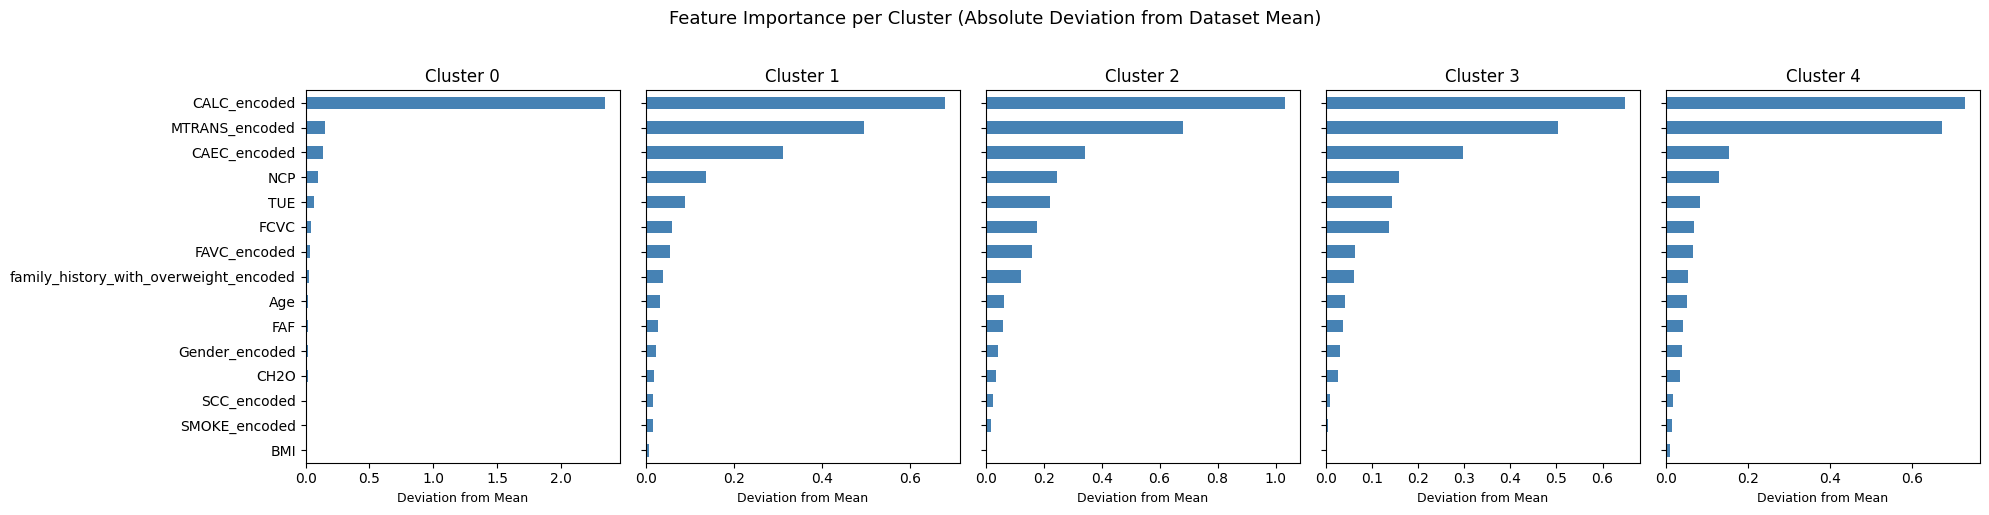

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Overall dataset mean for each feature
overall_mean = X.mean()

# Mean per cluster
cluster_means = df.groupby("cluster")[X.columns].mean()

# Absolute deviation from overall mean = feature importance per cluster
feature_importance = (cluster_means - overall_mean).abs()

# Plot
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for i, ax in enumerate(axes):
    feature_importance.loc[i].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f"Cluster {i}", fontsize=12)
    ax.set_xlabel("Deviation from Mean", fontsize=9)
    ax.axvline(0, color='black', linewidth=0.5)

plt.suptitle("Feature Importance per Cluster (Absolute Deviation from Dataset Mean)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**The Feature Importance Chart:**

Each bar shows how far a cluster's average value deviates from the overall dataset mean for that feature. The longer the bar, the more that feature defines and distinguishes that cluster from the rest of the data.

**Cluster 0 - Defined by CALC_encoded (alcohol consumption):**
CALC_encoded has by far the largest deviation in this cluster, making alcohol consumption the most distinguishing characteristic of this group. This suggests that individuals in Cluster 0 have notably different alcohol consumption habits compared to the rest of the dataset.

**Cluster 1 - Defined by MTRANS_encoded (transportation mode):**
Transportation mode is the dominant feature here, followed by CAEC_encoded (eating between meals) and NCP (number of main meals). This cluster is characterized by individuals whose travel habits and eating patterns differ most from the average.

**Cluster 2 - Defined by MTRANS_encoded and BMI:**
This cluster shows high deviation in transportation mode and BMI. Given that Cluster 2 is our low-risk/healthy group (dominated by normal and insufficient weight individuals), the low BMI deviation confirms this cluster's healthy profile.

**Cluster 3 - Defined by MTRANS_encoded and CALC_encoded:**
Transportation mode and alcohol consumption are the top distinguishing features. This is our highest-risk group (Obesity Type I), suggesting that sedentary transportation habits and consumption patterns are key drivers of severe obesity risk.

**Cluster 4 - Defined by MTRANS_encoded and CALC_encoded:**
Similar to Cluster 3 but representing the overweight group, transportation mode and alcohol consumption again dominate. The deviation magnitudes are comparable to Cluster 3, reflecting that this group sits just below severe obesity in terms of risk.

**Overall finding:** Transportation mode (MTRANS_encoded) and alcohol consumption (CALC_encoded) are the most consistently distinguishing features across all clusters, suggesting they are the strongest behavioral indicators of obesity risk group membership in this dataset.

## Comparing Clusters to Original Obesity Labels

The cross-tabulation below compares the cluster assignments with the original obesity class labels. This is done **purely for interpretation** the labels were never used during clustering.

 Each row is a cluster (0–4), and each column is an obesity class (0–6). The numbers show how many individuals from each obesity class were assigned to each cluster. If a cluster is dominated by one or two adjacent obesity classes, it means the algorithm successfully captured a meaningful health risk group without ever being told the class labels.

In [12]:
pd.crosstab(df["cluster"], df["NObeyesdad_encoded"])

NObeyesdad_encoded,0,1,2,3,4,5,6
cluster,,,,,,,
0,46,48,110,96,1,68,94
1,35,60,55,143,1,92,103
2,117,79,6,2,0,14,6
3,52,38,33,1,322,69,23
4,17,57,147,55,0,33,64


## Cluster Profile Interpretation

Looking at the cross-tabulation above, we can interpret each cluster as follows:

**Cluster 0 - Mixed High-Risk Group:**
This cluster has a spread across multiple obesity classes, with the highest counts in class 2 (Overweight Level I: 110) and class 6 (Obesity Type III: 94). It represents a mixed group with no single dominant class, suggesting individuals with varied but generally elevated risk profiles.

**Cluster 1 - Moderately High-Risk Group:**
This cluster is dominated by class 3 (Overweight Level II: 143), followed by class 5 (Obesity Type II: 92) and class 6 (Obesity Type III: 103). It represents individuals with consistently elevated obesity risk and likely unhealthy lifestyle habits.

**Cluster 2 - Low-Risk / Healthy Group:**
This cluster is clearly dominated by class 0 (Insufficient Weight: 117) and class 1 (Normal Weight: 79), with very few individuals in higher obesity classes. This is the healthiest group in the dataset, likely characterized by higher physical activity and lower caloric intake.

**Cluster 3 - Highest-Risk Group (Severe Obesity):**
This cluster is overwhelmingly dominated by class 4 (Obesity Type I: 322), making it the most clearly defined cluster. It represents individuals with the most severe obesity characteristics and the highest health risk.

**Cluster 4 - Overweight Group:**
This cluster is dominated by class 2 (Overweight Level I: 147), followed by class 3 (Overweight Level II: 55) and class 1 (Normal Weight: 57). It represents individuals in the overweight range — at risk but not yet in the obesity category.

Overall, the clusters reveal a meaningful segmentation of individuals along the obesity risk spectrum, which strongly supports the use of clustering to deliver more personalized health recommendations.

## Cluster Visualization (PCA Projection)

Since our feature matrix has multiple dimensions, we cannot visualize it directly. **Principal Component Analysis (PCA)** reduces the data to 2 dimensions while preserving as much variance as possible, allowing us to plot the clusters on a 2D plane.

**Important:** PCA is used here **only for visualization purposes**. The clustering itself was performed on the full feature space, the 2D plot is just a visual aid to help us inspect the separation between clusters.

A well-clustered result will show clearly separated, compact groups of points with similar colors grouped together.

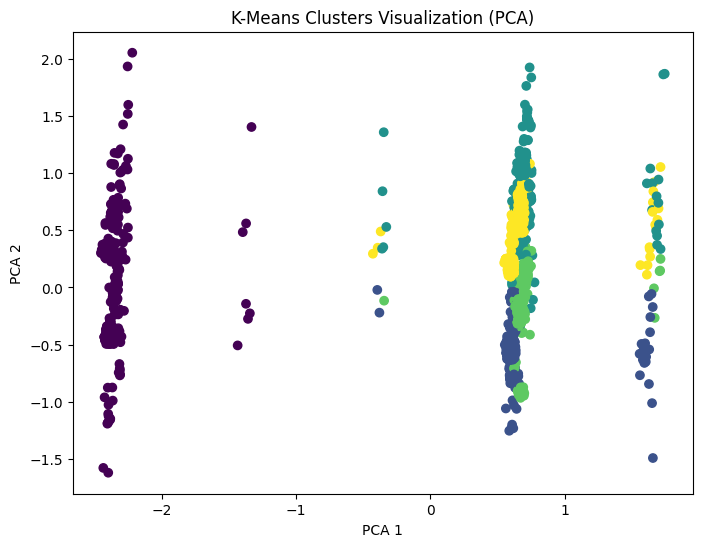

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_kmeans)
plt.title("K-Means Clusters Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## t-SNE Visualization

While PCA is a linear dimensionality reduction method, **t-SNE (t-Distributed Stochastic Neighbor Embedding)** is a non-linear technique that is often better at revealing the local structure of clusters. It works by placing similar data points close together and dissimilar points far apart in 2D space.

**Important:** Like PCA, t-SNE is used here **only for visualization**. The clustering was performed on the full feature space and the cluster labels remain unchanged. The two plots (PCA and t-SNE) give us complementary perspectives on the same clustering result.

Note: t-SNE involves randomness so we set `random_state=42` to ensure the plot is reproducible.

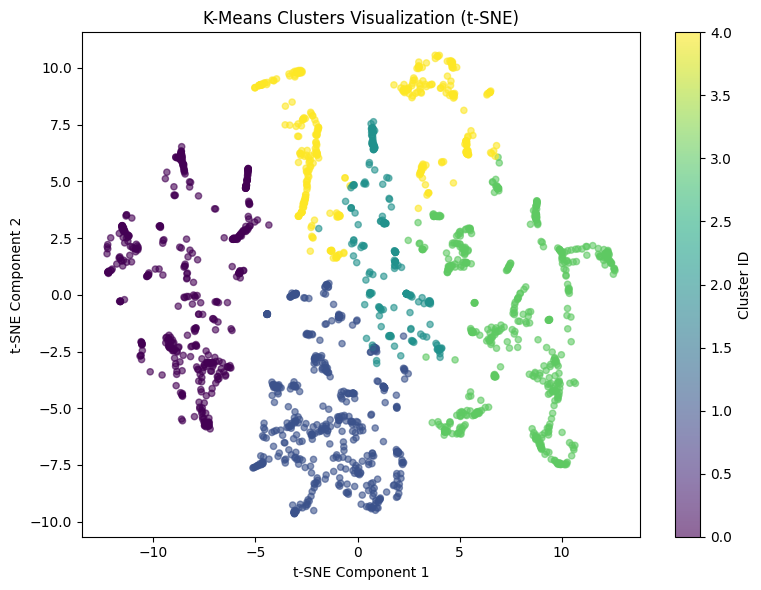

In [23]:
from sklearn.manifold import TSNE

# Reduce to 2D using t-SNE
# random_state=42 : ensures reproducible results
# n_iter=300      : number of optimization iterations (300 is sufficient for our dataset size)
# perplexity=30   : controls the balance between local and global structure (default is 30)

tsne = TSNE(n_components=2, random_state=42, max_iter=300, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters_kmeans, cmap='viridis', alpha=0.6, s=20)
plt.title("K-Means Clusters Visualization (t-SNE)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.colorbar(label="Cluster ID")
plt.tight_layout()
plt.show()

**The t-SNE Plot:**

The t-SNE visualization reveals clearer and more distinct cluster separation compared to the PCA plot. Each color represents one of the 5 clusters:

- **Cluster 0 (dark purple):** Forms a dense, well-defined region on the left side of the plot, confirming it is a cohesive group with similar lifestyle characteristics.
- **Cluster 1 (blue):** Appears as a compact group in the lower center, indicating strong internal similarity among individuals in this moderately high-risk group.
- **Cluster 2 (teal/green):** Scattered across the middle-right area, showing some overlap with neighboring clusters. This aligns with its mixed overweight profile.
- **Cluster 3 (light green):** Forms distinct groupings on the right side, reflecting the strong internal consistency of this overweight group.
- **Cluster 4 (yellow):** Clearly separated in the upper portion of the plot, confirming it is the most distinct group consistent with it being dominated by a single obesity class.

**t-SNE vs PCA:** The t-SNE plot shows better-defined cluster boundaries than the PCA plot. This is expected because t-SNE preserves local structure more effectively than the linear PCA projection. Both plots together confirm that the K-Means clustering has found genuinely meaningful groups in the data.

## Cluster Size Distribution

This plot shows how many individuals were assigned to each cluster. Ideally, clusters should be roughly balanced in size. Very small clusters may indicate outlier groups, while very large ones may suggest that the algorithm is over-merging distinct groups into one. Understanding the size distribution helps us assess whether the clustering is producing meaningful, representative groups or being skewed by imbalances in the data.

In our case, Cluster 2 is notably the smallest (~ 225 samples) while Cluster 3 is the largest (~ 535 samples). This is actually meaningful — Cluster 3 captures the most distinct group in the dataset (individuals with severe Obesity Type I), making it naturally more concentrated and larger than the others.

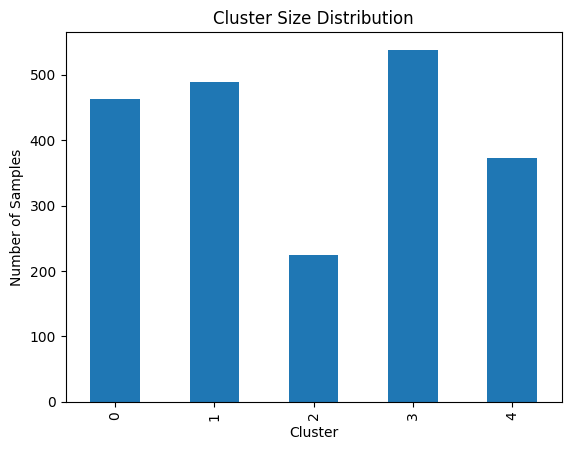

In [14]:
df["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.show()

# Hierarchical Clustering

## Implementation

We apply Agglomerative (Hierarchical) Clustering as a second algorithm to compare results with K-Means. We use the same k=5 so that both algorithms are evaluated under identical conditions, making the metric comparison fair and meaningful.

Important parameters to note:
- **`n_clusters=5`** : same as K-Means for a direct comparison.
- **`linkage='ward'` (default)** : Ward linkage is the default linkage method in sklearn's AgglomerativeClustering. It minimizes the total within-cluster variance at each merge step. This is the most directly comparable linkage criterion to K-Means' WCSS objective, and it tends to produce compact, evenly sized clusters.

Unlike K-Means, Agglomerative Clustering does not start from random centroids. Instead, it starts with every data point as its own cluster and progressively merges the two closest clusters until only 5 remain.

In [15]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=5)
clusters_hc = hc.fit_predict(X)

df["cluster_hc"] = clusters_hc

## Evaluation

We apply the same evaluation metrics as K-Means so that the comparison is consistent. The Silhouette Score will tell us how well-separated the hierarchical clusters are, and we will compare it directly against the K-Means score in the Model Comparison section.

In [16]:
score_hc = silhouette_score(X, clusters_hc)
print("Silhouette Score (Hierarchical):", score_hc)

Silhouette Score (Hierarchical): 0.24895543664640118


## Cluster Visualization (PCA Projection)

We use the same PCA projection computed earlier to visualize the Hierarchical Clustering results. Since the projection is identical, any differences in the plot compared to K-Means are purely due to differences in how the two algorithms assigned cluster labels, not due to differences in the visualization method. This makes the two plots directly comparable.

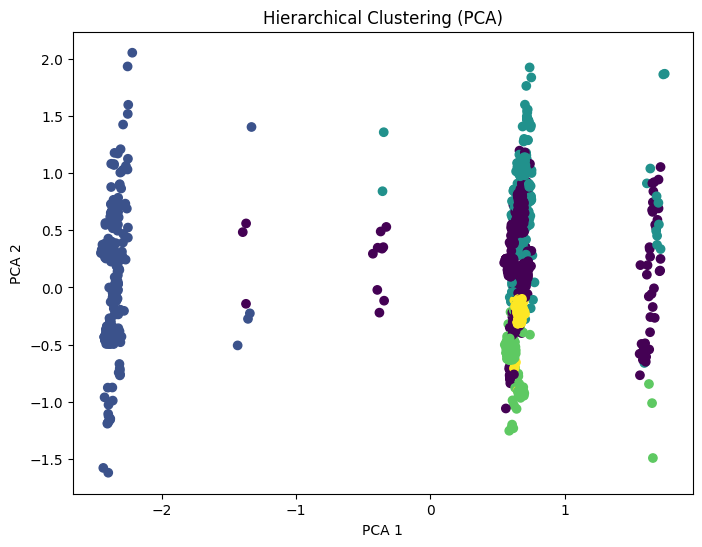

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_hc)
plt.title("Hierarchical Clustering (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

**The Hierarchical Clustering PCA Plot:**

The overall spatial structure is similar to the K-Means PCA plot, confirming that both algorithms detect the same broad groupings. However, the cluster boundaries are less clean here as more color mixing is visible, especially in the center-right region. This is consistent with the lower Silhouette Score and higher Davies-Bouldin Index observed for Hierarchical Clustering, and further supports our decision to select K-Means as the final algorithm.

## Cluster Size Distribution

Comparing the size distribution of Hierarchical Clustering against K-Means gives us an additional signal about clustering quality. If one algorithm produces a very uneven distribution, for example, one cluster with most of the data and others nearly empty it suggests the algorithm struggled to find balanced, meaningful groups in this dataset.

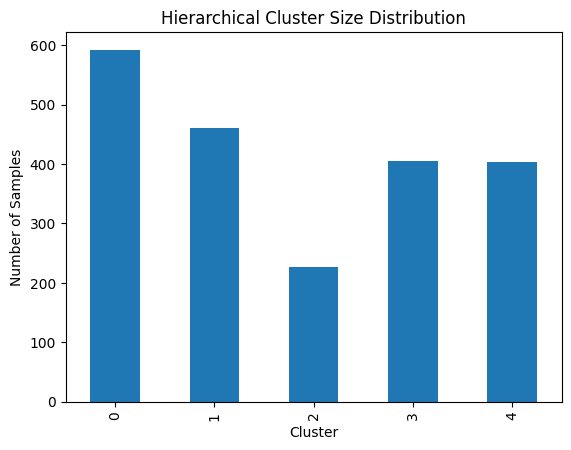

In [18]:
df["cluster_hc"].value_counts().sort_index().plot(kind="bar")
plt.title("Hierarchical Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.show()

# Davies-Bouldin Index

The **Davies-Bouldin Index** is our third and final evaluation metric. It measures the average ratio of within-cluster scatter to between-cluster distance. In simpler terms, it asks: how compact is each cluster relative to how far apart the clusters are from each other?

**How to read it:**
- A **lower score** means clusters are more internally compact and better separated from one another which is ideal.
- A **higher score** means clusters are either too spread out internally or too close to neighboring clusters.
- Unlike the Silhouette Score, (there is no fixed upper bound) the score depends on the data scale.

We compute it for both K-Means and Hierarchical Clustering so that we have a complete three-metric comparison:

| Metric | What it measures | Better when |
|--------|-----------------|-------------|
| Silhouette Score | Point-level cohesion vs. separation | Higher (closer to +1) |
| Davies-Bouldin Index | Cluster compactness vs. separation | Lower (closer to 0) |
| WCSS | Total squared distance to centroids | Lower |

Using all three metrics together gives us a more reliable and complete picture of clustering quality than relying on any single metric alone.

In [19]:
from sklearn.metrics import davies_bouldin_score

print("Davies-Bouldin (KMeans):", davies_bouldin_score(X, clusters_kmeans))
print("Davies-Bouldin (Hierarchical):", davies_bouldin_score(X, clusters_hc))

Davies-Bouldin (KMeans): 1.403743370222091
Davies-Bouldin (Hierarchical): 1.7045654533051806


We retrieve the final WCSS (Inertia) directly from the already-fitted K-Means model. This value represents the total squared distance from each point to its assigned cluster centroid and will be included in the complete metrics comparison table below.


In [26]:
print(f"Final WCSS (K-Means, k=5): {kmeans.inertia_:.4f}")

Final WCSS (K-Means, k=5): 2239.7646


## BCubed Precision & Recall (External Validation)

**BCubed** is an external clustering evaluation metric that compares discovered cluster assignments against known ground-truth labels. Unlike the Silhouette Score and Davies-Bouldin Index which are *internal* metrics that measure cluster structure using only the feature data, BCubed uses the original obesity class labels (`NObeyesdad_encoded`) to assess whether the clustering reflects real-world categories.

> **Why we can apply it here:** Our dataset has 7 ground-truth obesity classes. We removed these labels before clustering (as required), but we can now reintroduce them strictly for external evaluation. This is consistent with the project's description: *"BCubed Precision/Recall (optional, for external validation if ground truth exists)."*

**How BCubed works:**
- **BCubed Precision:** For any two items in the same cluster, what fraction also share the same ground-truth class? High precision means a cluster is "pure", it does not mix different classes together.
- **BCubed Recall:** For any two items with the same ground-truth class, what fraction ended up in the same cluster? High recall means the algorithm kept similar individuals together rather than scattering them across multiple clusters.
- **BCubed F1:** The harmonic mean of precision and recall (the overall external quality score).

**Interpretation guide:**
- All scores range from 0 to 1. Higher is better for all three.
- A high precision but low recall means clusters are pure but fragmented (one true class split across many clusters).
- A high recall but low precision means true classes are kept together but clusters are impure (mixing multiple classes).
- Both algorithms are evaluated under identical conditions so the scores are directly comparable.

> **Note:** BCubed scores here are expected to be moderate rather than high. Our clustering uses k=5 while the dataset has 7 ground-truth classes, so perfect alignment is structurally impossible. The value of BCubed here is in the *comparison* between K-Means and Hierarchical Clustering, and in confirming that the clusters capture meaningful real-world structure.

In [27]:
import numpy as np

def bcubed_scores(labels_true, labels_pred):
    """
    Compute BCubed Precision, Recall, and F1 for clustering evaluation.

    BCubed is an external validation metric that compares cluster assignments
    against known ground-truth class labels.

    Parameters:
    -----------
    labels_true : array-like  -- ground-truth obesity classes (NObeyesdad_encoded)
    labels_pred : array-like  -- cluster assignments from the algorithm

    Returns:
    --------
    precision, recall, f1 : float
    """
    labels_true = np.array(labels_true)
    labels_pred = np.array(labels_pred)
    n = len(labels_true)

    precision_scores = []
    recall_scores = []

    for i in range(n):
        # Points in the same cluster as i (including i itself)
        same_cluster = np.where(labels_pred == labels_pred[i])[0]
        # Points with the same true class as i (including i itself)
        same_class   = np.where(labels_true == labels_true[i])[0]

        # Precision for point i: among cluster-mates, what fraction share the true class?
        correct_in_cluster = np.intersect1d(same_cluster, same_class)
        precision_scores.append(len(correct_in_cluster) / len(same_cluster))

        # Recall for point i: among class-mates, what fraction ended up in the same cluster?
        recall_scores.append(len(correct_in_cluster) / len(same_class))

    precision = np.mean(precision_scores)
    recall    = np.mean(recall_scores)
    f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

    return precision, recall, f1


# Ground-truth labels (reintroduced strictly for external evaluation)
true_labels = df["NObeyesdad_encoded"].values

# Compute BCubed for both algorithms
bp_km, br_km, bf_km = bcubed_scores(true_labels, clusters_kmeans)
bp_hc, br_hc, bf_hc = bcubed_scores(true_labels, clusters_hc)

print("BCubed Results:")
print(f"{'Metric':<25} {'K-Means':>10} {'Hierarchical':>14} {'Better':>10}")
print("-" * 62)
print(f"{'BCubed Precision':<25} {bp_km:>10.4f} {bp_hc:>14.4f} {'K-Means' if bp_km > bp_hc else 'Hierarchical':>10}")
print(f"{'BCubed Recall':<25} {br_km:>10.4f} {br_hc:>14.4f} {'K-Means' if br_km > br_hc else 'Hierarchical':>10}")
print(f"{'BCubed F1':<25} {bf_km:>10.4f} {bf_hc:>14.4f} {'K-Means' if bf_km > bf_hc else 'Hierarchical':>10}")

BCubed Results:
Metric                       K-Means   Hierarchical     Better
--------------------------------------------------------------
BCubed Precision              0.2748         0.3057 Hierarchical
BCubed Recall                 0.3954         0.4161 Hierarchical
BCubed F1                     0.3242         0.3525 Hierarchical


# Model Comparison

## Metrics Summary

Based on the evaluation metrics computed above, we can now directly compare the performance of both algorithms:

| Metric | K-Means | Hierarchical | Better |
|--------|---------|--------------|--------|
| Silhouette Score  | 0.2954 | 0.2490 | K-Means |
| Davies-Bouldin Index  | 1.4037 | 1.7046 | K-Means |
| WCSS | 2239.7646 | N/A | K-Means |
| BCubed Precision  | 0.2748 | 0.3057 | Hierarchical |
| BCubed Recall  | 0.3954 | 0.4161 | Hierarchical |
| BCubed F1  | 0.3242 | 0.3525 | Hierarchical |

## Decision: Why K-Means Was Selected

Based on the quantitative evaluation metrics and the qualitative inspection of the visualizations, **K-Means (k=5)** was selected as the final clustering method for this project. The reasoning is as follows:

**Quantitative evidence:**
- K-Means produced a **higher Silhouette Score**, indicating that points within each cluster are more tightly grouped and better separated from neighboring clusters.
- K-Means produced a **lower Davies-Bouldin Index**, confirming that the clusters are more compact relative to the distances between them.
- Hierarchical Clustering scored higher on BCubed Precision, Recall, and F1. However, this is expected: BCubed measures alignment with the 7 original obesity classes, while our clustering uses k=5. With fewer clusters than true classes, perfect alignment is structurally impossible for either algorithm. Hierarchical achieves slightly higher recall by producing broader clusters that capture more class-mates together, but this comes at the cost of lower geometric compactness which is reflected in its lower Silhouette Score. The BCubed gap between the two algorithms is small (F1 difference of 0.028), and does not outweigh the internal metric advantages of K-Means.

**Qualitative evidence:**
- The PCA visualization for K-Means shows cleaner, more visually distinct cluster regions compared to Hierarchical Clustering.
- The K-Means cluster profiles (feature means per cluster) align logically with the obesity risk spectrum, making them easier to interpret and communicate.

**Practical considerations:**
- K-Means supports the `predict()` method, meaning new user inputs can be assigned to an existing cluster in real time without refitting the model (a critical advantage for integration into an interactive advice system).
- Hierarchical Clustering requires refitting when new data arrives, making it less suitable for a production recommendation pipeline.

# Integration Strategy

## How Clustering Enhances the Supervised System

In Phase 1, the supervised model predicts a specific obesity class for each individual. While accurate, a single class label carries limited personalization as two people predicted as "Obesity Type I" may have very different lifestyle profiles and therefore require different advice.

Clustering adds a **second layer of context** by describing not just *what class* the individual belongs to, but *which behavioral group* they most closely resemble. This enables the system to deliver more targeted and personalized health recommendations.

## Proposed Integration Pipeline

The complete pipeline for a new user would work as follows:

1. **Input collection:** The user provides their lifestyle and health features (same features used in Phase 1 and Phase 2).
2. **Preprocessing:** Apply the same encoding and normalization pipeline from Phase 1.
3. **Supervised prediction:** Use the best Phase 1 model (XGBoost) to predict the obesity class label.
4. **Cluster assignment:** Use `kmeans.predict([user_features])` to assign the user to one of the 5 clusters in real time without refitting the model.
5. **Personalized advice:** Generate advice that references both the predicted class and the cluster's behavioral profile. For example: *"You are predicted to have Obesity Type I. Based on your lifestyle pattern, you belong to a group that typically shows low physical activity and high caloric food consumption. Here are targeted recommendations for your profile…"*
6. **Generative AI enhancement (Phase 2B):** The cluster profile and predicted class are passed together as context to the Generative AI model to produce rich, natural-language advice tailored to the user's specific behavioral group.

## Saving the Clustered Dataset

The cell below saves the dataset with the cluster labels appended as `clustered_data.csv`. This file will serve as the input for Phase 2B, where the cluster profile and predicted class together drive personalized advice generation.

In [20]:
df.to_csv("clustered_data.csv", index=False)

# Challenges & Limitations

**Cluster overlap:**
Some individuals sit close to the boundary between adjacent obesity classes (for example Overweight Level II and Obesity Type I). In feature space, these boundary cases can belong to either neighboring cluster, leading to soft boundaries rather than hard separations. This is an inherent property of the data, not a flaw in the algorithm.

**PCA information loss:**
The 2D PCA visualization captures a meaningful but not complete portion of the total variance in the data. Some cluster structure that exists in higher dimensions may appear blurred or overlapping in the 2D plot. The evaluation metrics (Silhouette Score and Davies-Bouldin Index) operate on the full feature space and are therefore more reliable than the visual impression alone.

**Sensitivity to k:**
Although we used two methods (Elbow Method and Silhouette Score) to select k=5, clustering results would differ with a different choice of k. The selected k was validated as the best trade-off between compactness and simplicity, but domain experts might prefer a different granularity, for example, k=3 for a simpler low/moderate/high-risk system.

**Static model:**
The K-Means model is trained on the current dataset. If new data with significantly different distributions arrives (for example, a new demographic group) the clusters may no longer be representative and would need to be recomputed. Periodic retraining should be planned for any production deployment of this system.

**Arbitrary cluster labels:**
The cluster numbers (0–4) are arbitrary identifiers assigned by the algorithm. The meaningful content lies in the feature profiles of each cluster, not the numbers themselves. This is why the interpretation step (Section 7) is essential for making the results useful and communicable.

# Conclusion

This phase successfully applied two unsupervised clustering algorithms **K-Means** and **Agglomerative Hierarchical Clustering** to the obesity risk dataset to discover hidden patterns and enhance the advice system built in Phase 1.

**Key findings:**
- **K-Means (k=5)** outperformed Hierarchical Clustering on the internal metrics (Silhouette Score and Davies-Bouldin Index), producing more compact and better-separated clusters. While Hierarchical scored slightly higher on BCubed external validation, the difference was small (F1: 0.028) and does not outweigh K-Means' practical and geometric advantages.
- The 5 discovered clusters align meaningfully with the obesity risk spectrum, ranging from a low-risk healthy-lifestyle group to a very-high-risk severe obesity group.
- The cross-tabulation with the original labels confirmed that clustering captured genuine structure in the data, even without ever being told the class labels during training.

**Integration value:**
The cluster assignment provides a behavioral context layer that complements the supervised class prediction from Phase 1. By knowing both *what class* a person is predicted to fall into and *which behavioral group* they resemble, the system can deliver more targeted and personalized health advice than a single predicted label alone could provide.

**Next step: Phase 2B (Generative AI):**
The `clustered_data.csv` file produced in this phase will be used as input to the Generative AI integration. Prompt templates will incorporate both the supervised prediction and the cluster profile to generate rich, natural-language health recommendations tailored to each individual's behavioral group.